In [49]:
import pandas as pd
import numpy as np

file_path = r"E:\file_main\Major_1\fauna-forecast\data\raw\bison_population_interpolated.csv"
df = pd.read_csv(file_path)

# Convert Year to datetime and set as index
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)

# Optional: ensure yearly frequency
df = df.asfreq('YS')  # Year Start frequency

print(df.head())

              Population        Source
Year                                  
1800-01-01  6.000000e+07    Historical
1801-01-01  5.933333e+07  Interpolated
1802-01-01  5.866667e+07  Interpolated
1803-01-01  5.800000e+07  Interpolated
1804-01-01  5.733333e+07  Interpolated


In [50]:
# Log-transform to handle large range
df['Log_Pop'] = np.log1p(df['Population'])

# Drop any missing values just in case
series = df['Log_Pop'].dropna()
print(series.head())
print("Series length:", len(series))

Year
1800-01-01    17.909855
1801-01-01    17.898682
1802-01-01    17.887382
1803-01-01    17.875954
1804-01-01    17.864393
Freq: YS-JAN, Name: Log_Pop, dtype: float64
Series length: 218


In [54]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(series.diff().dropna())  # first-order differencing
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] <= 0.05:
    print("✅ Series is stationary after 1st differencing")
else:
    print("❌ Series is non-stationary – consider 2nd differencing")

ADF Statistic: -7.868687763099844
p-value: 5.053165783026281e-12
✅ Series is stationary after 1st differencing


In [56]:
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

# Auto ARIMA to choose best p, d, q
model_auto = pm.auto_arima(series,
                           start_p=0, max_p=5,
                           start_q=0, max_q=5,
                           d=1,  # use first-order differencing only
                           seasonal=False,
                           stepwise=True,
                           suppress_warnings=True,
                           trace=True)

p, d, q = model_auto.order
print(f"Chosen ARIMA order: p={p}, d={d}, q={q}")

# Fit ARIMA with chosen order
model = ARIMA(series, order=(p,d,q))
model_fit = model.fit()
print(model_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=139.535, Time=0.18 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=126.949, Time=0.22 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=129.971, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=138.499, Time=0.17 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=125.814, Time=0.17 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=126.527, Time=0.20 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=123.752, Time=0.39 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=122.445, Time=0.20 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=123.768, Time=0.59 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=128.290, Time=0.24 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=125.160, Time=0.70 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=120.646, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=128.666, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=125.514, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=121.9

In [58]:
# Forecast next 10 years
forecast_steps = 10
forecast_log = model_fit.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=series.index[-1] + pd.DateOffset(years=1),
                               periods=forecast_steps, freq='YS')

# Convert back from log
forecast_pop = np.expm1(forecast_log.predicted_mean)

# Create DataFrame
forecast_df = pd.DataFrame({
    'Forecast_Log': forecast_log.predicted_mean,
    'Forecast_Pop': forecast_pop
}, index=forecast_index)

print(forecast_df)

            Forecast_Log   Forecast_Pop
2018-01-01     13.159900  519124.172385
2019-01-01     13.192264  536200.021556
2020-01-01     13.220170  551373.762449
2021-01-01     13.244231  564801.453366
2022-01-01     13.264978  576641.580874
2023-01-01     13.282866  587049.687023
2024-01-01     13.298291  596174.664763
2025-01-01     13.311590  604156.371498
2026-01-01     13.323057  611124.253011
2027-01-01     13.332945  617196.718869


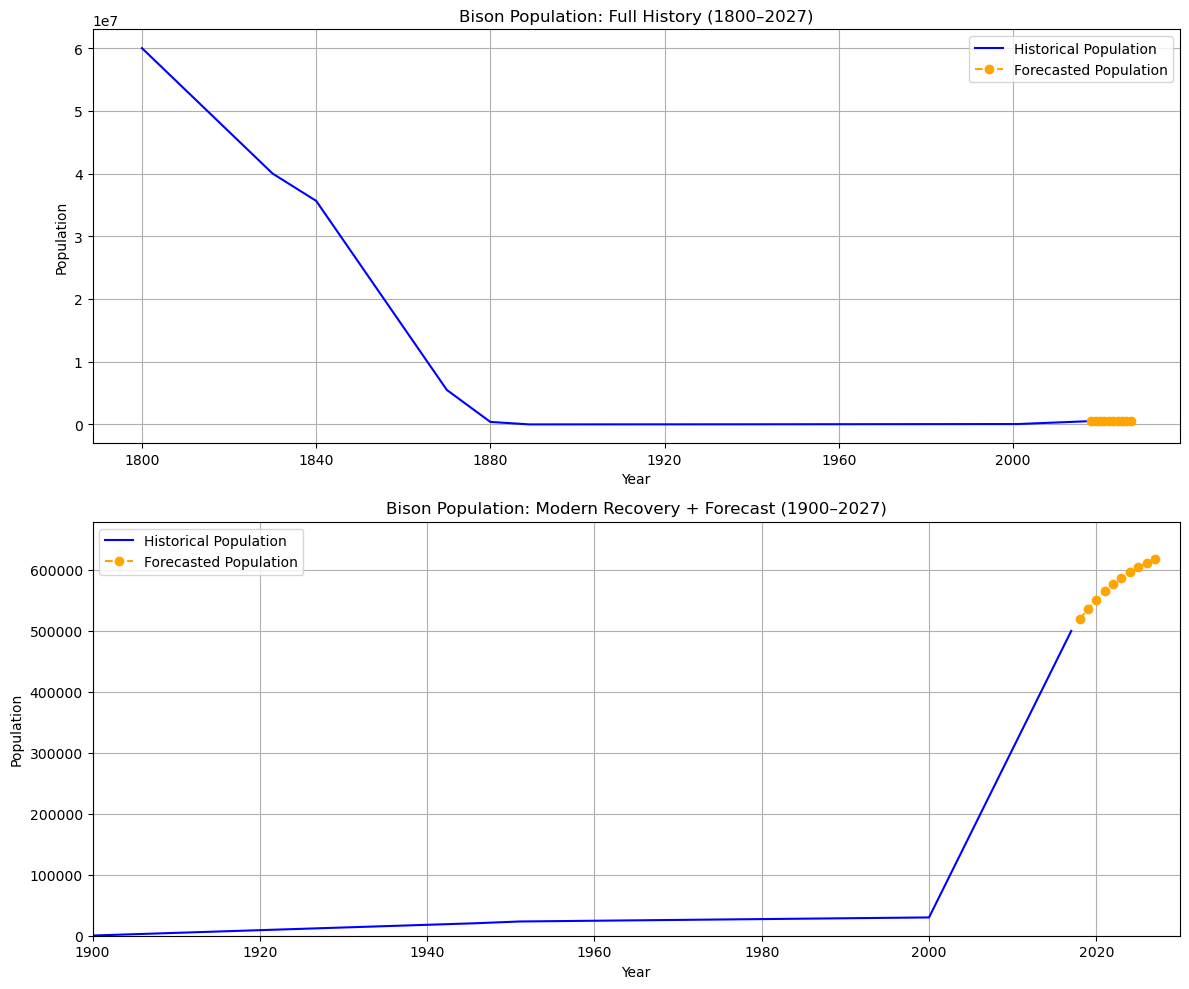

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

# Historical data
historical = df['Population']

# Forecasted data
forecast_index = pd.date_range(start='2018-01-01', end='2027-01-01', freq='YS')
forecast_pop = [519124.17, 536200.02, 551373.76, 564801.45, 576641.58, 
                587049.69, 596174.66, 604156.37, 611124.25, 617196.72]

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12,10), sharey=False)

# Panel 1: Full history
axes[0].plot(historical.index, historical.values, label='Historical Population', color='blue')
axes[0].plot(forecast_index, forecast_pop, label='Forecasted Population', color='orange', linestyle='--', marker='o')
axes[0].set_title('Bison Population: Full History (1800–2027)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Population')
axes[0].legend()
axes[0].grid(True)

# Panel 2: Zoom into modern recovery + forecast with auto y-scaling
axes[1].plot(historical.index, historical.values, label='Historical Population', color='blue')
axes[1].plot(forecast_index, forecast_pop, label='Forecasted Population', color='orange', linestyle='--', marker='o')
axes[1].set_xlim(pd.to_datetime("1900-01-01"), pd.to_datetime("2030-01-01"))

# Auto-adjust y-axis to show only modern range
modern_data = historical[historical.index >= "1900-01-01"]
y_min = 0
y_max = max(modern_data.max(), max(forecast_pop)) * 1.1  # add 10% padding
axes[1].set_ylim(y_min, y_max)

axes[1].set_title('Bison Population: Modern Recovery + Forecast (1900–2027)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Population')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()